In [46]:
import unicodedata
from IPython.display import display_markdown, display, Markdown, Latex
import json
from anthropic import Anthropic, HUMAN_PROMPT, AI_PROMPT

![Singapore's Smoke Cart. Photo by [Jia Wei Ng](https://unsplash.com/@jiaweing?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash) on [Unsplash](https://unsplash.com/photos/red-and-white-train-in-train-station-PC8BKbvS3y4?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash)](./tel_line.jpg){#fig fig-align="center" width=70%}

## Introduction
::: {.callout-tip}
## Executive Summary

What's the shortest route you can take on Singapore's MRT network such that you visit every station at least once? Can this be generalized for other metro networks as well? Is there a simple way to parse this information?
:::

### The Smoke Cart

Paul Theroux once travelled the breadth of China by train and wrote a book he called _Riding the Iron Rooster_. I'm getting old; I read it a long time back, and despite my wife's and daughter's advanced fluency in the language, somehow presumed they called a train as an "iron rooster" in Chinese all these years. 

I now know that it is simply [not true](https://keywords.oxus.net/archives/2005/06/20/fire-carriage/). I had misremembered; Theroux named his book after a specific train from Beijing to Urumqi that locals colloquially called as the 'iron rooster' because it was slow and inefficient. So I really can't call this _Riding the Iron Rooster_ now, can I, as I was going to earlier. Trains in general are called 火車 ( _huǒchē_ ) in Chinese, or a 'fire carriage'. But even there, you [shouldn't really take words apart](http://itre.cis.upenn.edu/~myl/languagelog/archives/002248.html) and hope to find something profound. A train is simply 'fire-carriage', not a 'fire' and a 'carriage' or 'carriage on fire'. 

Happily, using my own mother tongue offers me more certainty and less chance of false memories. Whilst I probably shouldn't call it a fire-carriage or an iron-rooster, there's still something strangely alluring to call the super-efficient, fully electric, mostly driverless, air-conditioned, crowded but spotlessly clean MRT as something else: in early 20th century Telugu, it would be a ధూమ శకటము (_dhūma śakaṭamu_), or a Smoke Cart. What is the best route to ride the Smoke Cart in Singapore? We're about to find out.

### Travelling Salesman Problem
Travelling salesmen in 1830's Germany and Switzerland first pondered upon this, and later by Irish mathematician W.R. Hamilton and British mathematician Thmoas Kirkman in 1859. The problem is apparently common enough, that GitHub Copilot had suggested the following description when I started to type this paragraph:

> The problem is simple to state: given a list of cities and the distances between each pair of cities, what is the shortest possible route that visits each city exactly once and returns to the origin city? It is an NP-hard problem in combinatorial optimization, important in operations research and theoretical computer science.

All clear? Great. Let's try to apply it to Singapore's MRT network: how do you visit all the stations in the network in the shortest possible route?

## Ghostriders in the Network
As on date, I've personally lost count of how many stations there are in the network. At some point, there definitely were 53, at which point, they promptly asked the question on the local version of _Who Wants To be a Millionaire_ . I shouted out 52 at the television then, clearly forgetting Dover MRT that they claimed had just opened. To be honest, I'm still not sure; the doors open the wrong way, and frankly, I've never seen anyone get off there. They also say there was nothing there first, and then [a dense equatorial forest](https://doverforest.sg), but who knows; human memory is fallible, this too may be a mirage.

![If a forest falls in the middle of an MRT network, did it make a sound? Photo by [HorseRat](https://unsplash.com/@horseratbros?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash") on [Unsplash](https://unsplash.com/photos/a-view-of-a-train-track-from-a-platform-qdT_Lauwb3I?utm_content=creditCopyText&utm_medium=referral&utm_source=unsplash)](./dover.jpg){#fig-dover fig-align="center" width=30%}

Better to rely on what Wikipedia says about current and future stations on the network. This is apparently correct as at 15 Mar 2024:

![My god, it's full of stops. By [Aforl](https://commons.wikimedia.org/wiki/File:Singapore_MRT_and_LRT_System_Map.svg), via Wikimedia Commons under [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0)](./network_map.svg){#fig-network fig-align="center"}

Not the MRT network in my teenage years or in my twenties, that's for sure. For one, (including the mythical Dover MRT) there are as many stations _beyond_ Boon Lay MRT, as there are between Queenstown and Boon Lay, where the East West Line used to terminate. This definitely would have been news to my 27-year-old self, who used to joke to this girl that he'd travel to the end of the map to meet her.^[Sometimes, with the right person, even corny lines can work. That girl and I have been married for 15 years now and counting.]

We need certainty in this regard, and a clear list to work off. 

[Wikipedia](https://en.wikipedia.org/wiki/List_of_Singapore_MRT_stations) has an updated list in all four official languages in Singapore, which we can parse and use. The list interestingly also has information on interchanges; for instance, from this row, we know that you can switch between North South, North East and Circle lines at Dhoby Ghaut: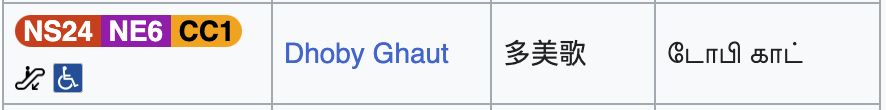

... and that, whilst you can switch between the North South and Downtown lines at Newton, you'd have to step out of the fare-gates and then step in again: 
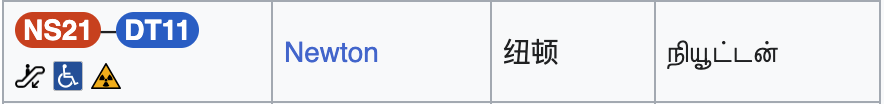

Separately, you would also realize that not all names in Tamil are transliterations of the English ones. The central MRT station that is called City Hall in English, for one, is nagara mandapam (நகர மண்டபம்) in Tamil. 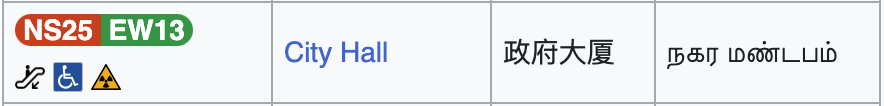

Is there a way to parse this information into a structured list? GenAI may help us here. 